# Stable Diffusion XL (SDXL) — Text-to-Image Generation

## What is this model?
Stable Diffusion XL (SDXL) is a **text-to-image diffusion model**.  
It creates images by starting from random noise and gradually denoising it until an image matching the prompt appears.

## Why is SDXL important?
SDXL is a major step forward from earlier Stable Diffusion models such as 1.4, 1.5, and 2.1.  
Compared with older versions, it uses:
- a **larger denoising network**
- a **second text encoder**
- better handling of **high-resolution images**
- stronger overall prompt following

The SDXL paper describes a **2.6 billion parameter U-Net backbone**. In practice, SDXL is widely considered much larger and more capable than earlier Stable Diffusion versions.  
It was presented in 2023, and the **SDXL 1.0 base weights** were released publicly on Hugging Face in **July 2023**.

## What this notebook does
1. load a pre-trained SDXL model
2. write a text prompt
3. generate an image
4. automatically save the image with a timestamp

## Notes
- This notebook uses the model: `stabilityai/stable-diffusion-xl-base-1.0`
- The downloaded weight file is large (about **6.94 GB**), so the first run may take a little time
- SDXL works well on Colab GPUs such as **T4** with memory-saving options enabled

In [ ]:
#@title Setup — Import libraries and load SDXL

!pip -q install diffusers transformers accelerate safetensors

import os
from datetime import datetime

import torch
from diffusers import StableDiffusionXLPipeline
import matplotlib.pyplot as plt

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

model_id = "stabilityai/stable-diffusion-xl-base-1.0"

print("\nLoading model:", model_id)

pipe = StableDiffusionXLPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)

# Memory-friendly options for Colab
pipe.enable_model_cpu_offload()

# Optional: uncomment if needed and available
# pipe.enable_xformers_memory_efficient_attention()

print("Model loaded successfully.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Torch version: 2.10.0+cu128
CUDA available: True

Loading model: stabilityai/stable-diffusion-xl-base-1.0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Model loaded successfully.


Prompt:
an angry boy with tatoo


  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


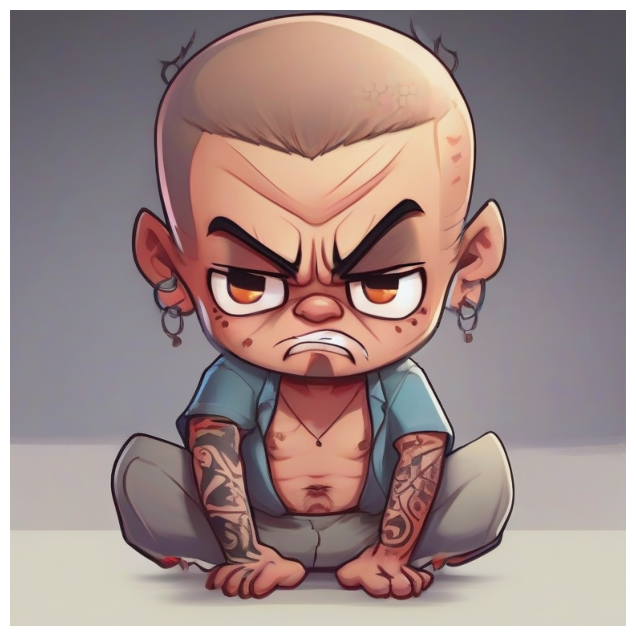

Saved image to: sdxl_outputs/sdxl_20260307_170948.png
Saved prompt to: sdxl_outputs/sdxl_20260307_170948.txt


In [ ]:
#@title Generate an image from a prompt { display-mode: "form" }

prompt = "an angry boy with tatoo"  #@param {type:"string"}
negative_prompt = "blurry, low quality, distorted, extra fingers, duplicate objects, text, watermark"  #@param {type:"string"}
num_inference_steps = 15  #@param {type:"slider", min:10, max:50, step:1}
guidance_scale = 7.5  #@param {type:"slider", min:1.0, max:12.0, step:0.5}
height = 768
width = 768


print("Prompt:")
print(prompt)

image = pipe(
    prompt=prompt,
    width=width,
    height=height,
    negative_prompt=negative_prompt,
    num_inference_steps=num_inference_steps,
    guidance_scale=guidance_scale,
).images[0]

plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

out_dir = "sdxl_outputs"
os.makedirs(out_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = os.path.join(out_dir, f"sdxl_{timestamp}.png")

image.save(filename)

print(f"Saved image to: {filename}")

#@title Save the prompt used for this image

txt_filename = filename.replace(".png", ".txt")

with open(txt_filename, "w", encoding="utf-8") as f:
    f.write("MODEL: stabilityai/stable-diffusion-xl-base-1.0\n")
    f.write(f"TIMESTAMP: {timestamp}\n")
    f.write(f"PROMPT: {prompt}\n")
    f.write(f"NEGATIVE_PROMPT: {negative_prompt}\n")
    f.write(f"STEPS: {num_inference_steps}\n")
    f.write(f"GUIDANCE_SCALE: {guidance_scale}\n")

print(f"Saved prompt to: {txt_filename}")

**Inference steps**
The model gradually removes noise to form the final image.
More steps usually improve quality but make generation slower.

**Guidance scale**
Controls how strongly the model follows the prompt.
Lower values allow more freedom; higher values follow the text more strictly.

## Run It on your laptop

**1. Download the python script**

Open a terminal and activate the conda environement we created last week:

```
conda activate yolo-env1
```

Create a folder to store the python file

| Windows | Mac / Linux |
|--------|-------------|
| `mkdir %USERPROFILE%\Documents\EvolutionAI\SDXL` | `mkdir -p ~/Documents/EvolutionAI/SDXL` |

Go to the directory just created

| Windows | Mac / Linux |
|--------|-------------|
| `cd %USERPROFILE%\Documents\EvolutionAI\SDXL` | `cd ~/Documents/EvolutionAI/SDXL` |

Download the python code

With UI:

```
curl -o vgg16andtsne.py https://raw.githubusercontent.com/ddribes/Evolution_of_AI/main/python/sdxl/sdxl_UI.py
```



Now Run it:

```
python sdxl_UI.py
```